# Employee Attrition Prediction Using Machine Learning

## Objective

The objective of this project is to develop a supervised machine learning model
that predicts whether an employee is likely to leave an organization based on
their demographic, professional, compensation, satisfaction, and work-related
characteristics.

The project compares multiple classification algorithms and evaluates their
performance using several machine learning metrics.

## 1. Importing Required Libraries

The required Python libraries are imported for data manipulation,
visualization, preprocessing, machine learning, and model evaluation.

In [1]:
#Data manipulation
import pandas as pd
import numpy as np

#visualization
import matplotlib.pyplot as plt
import seaborn as sns

#Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

#Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

#Evaluation
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

#ignore unnecessary Warnings
import warnings
warnings.filterwarnings("ignore")

## 2. Loading the Dataset

The HR Employee Attrition dataset is loaded into a Pandas DataFrame.
Each row represents an employee and each column represents an employee
characteristic.

In [2]:
df = pd.read_csv("HR-Employee-Attrition-All.csv")

In [3]:
print("Data set shape:",df.shape)
df.head()

Data set shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


## 3. Understanding the Dataset

The structure and statistical characteristics of the dataset are examined
using information about data types and descriptive statistics.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [5]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


## 4. Examining Categorical Variables

Categorical variables are examined separately to understand the
non-numerical information contained in the dataset.

In [6]:
df.describe(include="object")

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1233,1043,961,606,882,326,673,1470,1054


## 5. Checking for Missing Values

The dataset is checked for missing values to ensure that incomplete
records do not affect the machine learning process.

In [7]:
print("missing values:")
print(df.isnull().sum())

missing values:
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole      

## 6. Checking for Duplicate Records

Duplicate rows are identified to ensure that repeated records do not
affect the analysis or model training.

In [8]:
print("Duplicates values:")
print(df.duplicated().sum())

Duplicates values:
0


## 7. Analyzing the Target Variable

The target variable, Attrition, represents whether an employee left
the organization.

No represents employees who stayed, while Yes represents employees
who left.

In [9]:
print("Attrition Distribution:")
print(df['Attrition'].value_counts())

Attrition Distribution:
Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [10]:
print("Attrition percentage:")
print(df['Attrition'].value_counts(normalize=True) * 100)

Attrition percentage:
Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


#**Exploratory Data Analysis**



## 8. Visualizing Attrition Distribution

A count plot is used to visually compare the number of employees who
stayed with those who left.

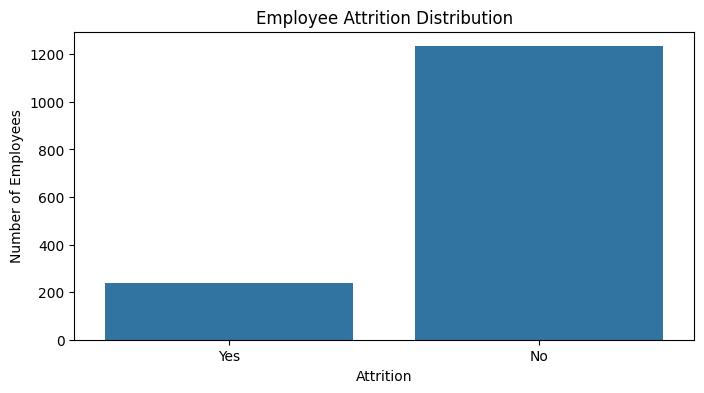

In [11]:
plt.figure(figsize=(8,4))
sns.countplot(data=df,x='Attrition')
plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")
plt.show()

## 9. Analyzing Overtime and Attrition

The relationship between overtime work and employee attrition is
visualized to identify possible differences between employees who
work overtime and those who do not.




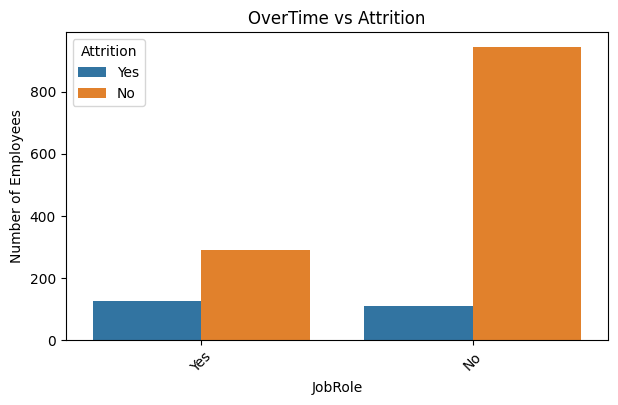

In [57]:
  plt.figure(figsize=(7,4))
  sns.countplot(data=df,x="OverTime",hue="Attrition")
  plt.title("OverTime vs Attrition")
  plt.xticks(rotation=45)
  plt.xlabel("OverTime")
  plt.ylabel("Number of Employees")
  plt.show()

## 10. Analyzing Job Satisfaction

The relationship between job satisfaction levels and employee attrition
is visualized to identify possible patterns in employee turnover.


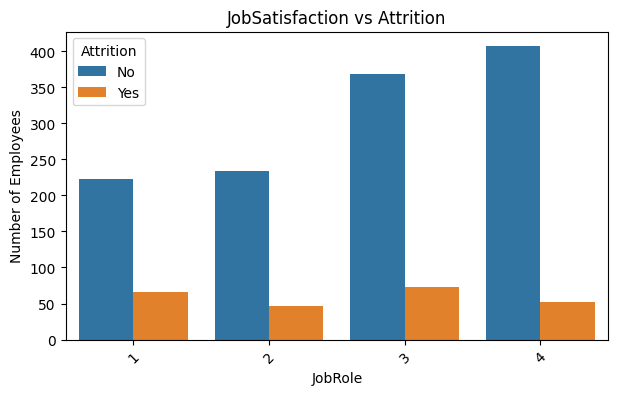

In [58]:
  plt.figure(figsize=(7,4))
  sns.countplot(data=df,x="JobSatisfaction",hue="Attrition")
  plt.title("JobSatisfaction vs Attrition")
  plt.xticks(rotation=45)
  plt.xlabel("JobSatisfaction")
  plt.ylabel("Number of Employees")
  plt.show()

## 11. Analyzing Job Role and Attrition

Employee attrition is compared across different job roles to identify
differences in attrition patterns among occupational groups.

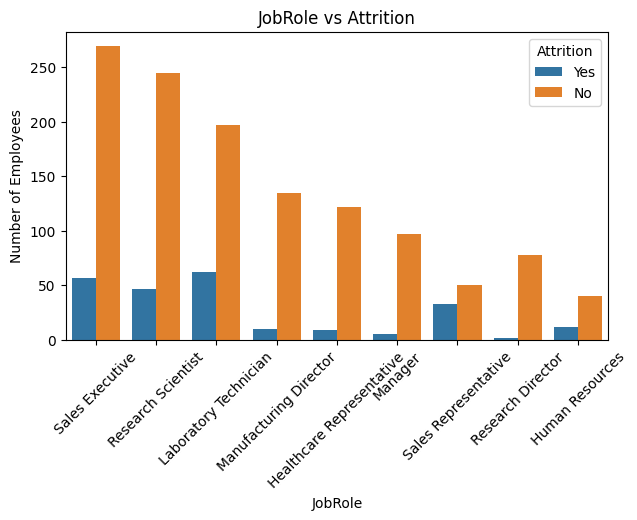

In [59]:
  plt.figure(figsize=(7,4))
  sns.countplot(data=df,x="JobRole",hue="Attrition")
  plt.title("JobRole vs Attrition")
  plt.xticks(rotation=45)
  plt.xlabel("JobRole")
  plt.ylabel("Number of Employees")
  plt.show()

## 12. Analyzing Age and Attrition

A boxplot is used to compare the age distribution of employees who
stayed with employees who left.

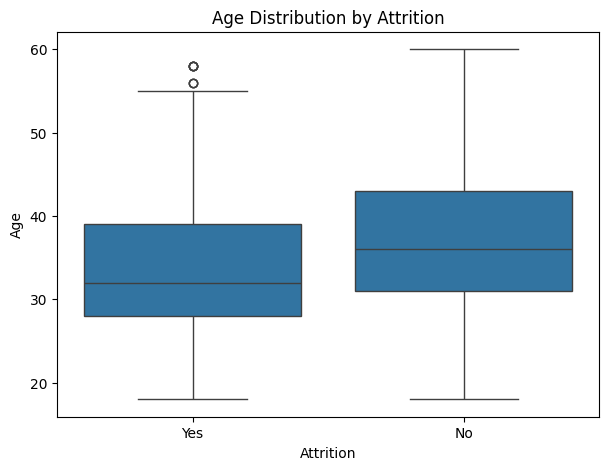

In [18]:
plt.figure(figsize=(7,5))
sns.boxplot(
    data=df,
    x="Attrition",
    y="Age"
)
plt.title("Age Distribution by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Age")
plt.show()

## 13. Analyzing Monthly Income and Attrition

Monthly income is compared between employees who stayed and employees
who left to identify differences in income distributions.

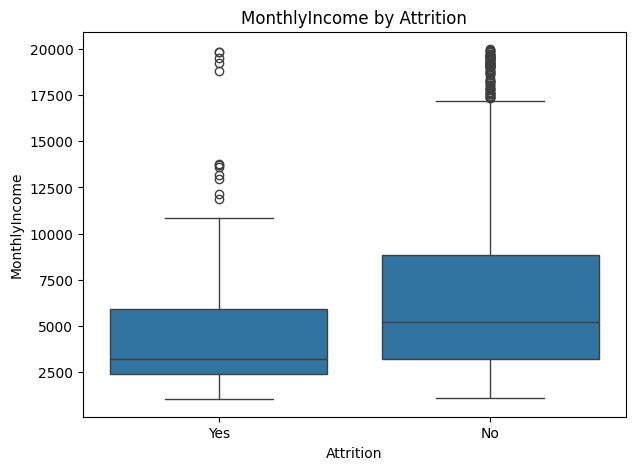

In [19]:
plt.figure(figsize=(7,5))
sns.boxplot(
    data=df,
    x="Attrition",
    y="MonthlyIncome"
)
plt.title("MonthlyIncome by Attrition")
plt.xlabel("Attrition")
plt.ylabel("MonthlyIncome")
plt.show()

#**Data Cleaning**

## 14. Removing Non-Informative Features

Columns that do not provide meaningful predictive information are
removed before model training.

EmployeeNumber is an identifier, while EmployeeCount, Over18, and
StandardHours do not provide useful variation in this dataset.

In [20]:
df = df.drop(columns=[
    "EmployeeCount",
    "EmployeeNumber",
    "Over18",
    "StandardHours"
])

In [60]:
df.to_csv("HR-Employee-Attrition-All-Cleaned.csv")

## 15. Separating Features and Target

The dataset is divided into input features (X) and the target variable (y).

X contains the employee characteristics used for prediction, while y
contains the employee attrition outcome.

In [21]:
x = df.drop("Attrition",axis=True)
y = df['Attrition'].map({
    "No":0,
    "Yes":1
})

In [22]:
print(x.shape)
print(y.shape)

(1470, 30)
(1470,)


## 16. Identifying Numerical and Categorical Features

Numerical and categorical columns are identified separately because
they require different preprocessing techniques.

In [23]:
categorical_features = x.select_dtypes(
    include=["object"]
).columns.to_list()

numerical_features = x.select_dtypes(
    include=["int64","float64"]
).columns.to_list()

print("Categorical features:")
print(categorical_features)

print("Numerical features:")
print(numerical_features)

Categorical features:
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
Numerical features:
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


## 17. Data Preprocessing

Numerical features are standardized using StandardScaler, while
categorical features are converted into numerical representations
using One-Hot Encoding.

A ColumnTransformer is used to apply the appropriate transformation
to each type of feature.

In [24]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
             StandardScaler(),
             numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

## 18. Splitting the Dataset

The dataset is divided into training and testing sets using an 80:20
ratio.

The training set is used to train the models, while the testing set is
used to evaluate their performance on unseen data.

Stratified splitting is used to preserve the proportion of the two
attrition classes.

In [25]:
x_train,x_test,y_train,y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## 19. Logistic Regression Model

Logistic Regression is used as a baseline classification model for
predicting employee attrition.

Balanced class weights are used because the target variable contains
fewer attrition cases than non-attrition cases.

In [26]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor",preprocessor),
        (
            "model",LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)
logistic_model.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'DailyRate',
                                                   'DistanceFromHome',
                                                   'Education',
                                                   'EnvironmentSatisfaction',
                                                   'HourlyRate',
                                                   'JobInvolvement', 'JobLevel',
                                                   'JobSatisfaction',
                                                   'MonthlyIncome',
                                                   'MonthlyRate',
                                                   'NumCompaniesWorked',
                                                   'PercentSalaryHike',
                                                   'PerformanceRating',
                                                   'RelationshipSatisfaction',
                                                   'StockOpt...
                                                   'TrainingTimesLastYear',
                                                   'WorkLifeBalance',
                                                   'YearsAtCompany',
                                                   'YearsInCurrentRole',
                                                   'YearsSinceLastPromotion',
                                                   'YearsWithCurrManager']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['BusinessTravel',
                                                   'Department',
                                                   'EducationField', 'Gender',
                                                   'JobRole', 'MaritalStatus',
                                                   'OverTime'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

## 20. Decision Tree Model

A Decision Tree classifier is trained to predict employee attrition.
The model makes predictions by creating a series of decision rules
based on the input features.

In [28]:
decision_tree_model = Pipeline(
    steps=[
        ("preprocessor",preprocessor),
        (
            "model",DecisionTreeClassifier(
                max_depth=5,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)
decision_tree_model.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'DailyRate',
                                                   'DistanceFromHome',
                                                   'Education',
                                                   'EnvironmentSatisfaction',
                                                   'HourlyRate',
                                                   'JobInvolvement', 'JobLevel',
                                                   'JobSatisfaction',
                                                   'MonthlyIncome',
                                                   'MonthlyRate',
                                                   'NumCompaniesWorked',
                                                   'PercentSalaryHike',
                                                   'PerformanceRating',
                                                   'RelationshipSatisfaction',
                                                   'StockOpt...
                                                   'TrainingTimesLastYear',
                                                   'WorkLifeBalance',
                                                   'YearsAtCompany',
                                                   'YearsInCurrentRole',
                                                   'YearsSinceLastPromotion',
                                                   'YearsWithCurrManager']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['BusinessTravel',
                                                   'Department',
                                                   'EducationField', 'Gender',
                                                   'JobRole', 'MaritalStatus',
                                                   'OverTime'])])),
                ('model',
                 DecisionTreeClassifier(class_weight='balanced', max_depth=5,
                                        random_state=42))])

## 21. Random Forest Model

A Random Forest classifier is trained using multiple decision trees.
The ensemble approach combines the predictions of many trees to
produce a final classification.

Balanced class weights are used to account for the imbalanced target.

In [29]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor",preprocessor),
        (
            "model",RandomForestClassifier(
                n_estimators=300,
                max_depth=10,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)
random_forest_model.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'DailyRate',
                                                   'DistanceFromHome',
                                                   'Education',
                                                   'EnvironmentSatisfaction',
                                                   'HourlyRate',
                                                   'JobInvolvement', 'JobLevel',
                                                   'JobSatisfaction',
                                                   'MonthlyIncome',
                                                   'MonthlyRate',
                                                   'NumCompaniesWorked',
                                                   'PercentSalaryHike',
                                                   'PerformanceRating',
                                                   'RelationshipSatisfaction',
                                                   'StockOpt...
                                                   'WorkLifeBalance',
                                                   'YearsAtCompany',
                                                   'YearsInCurrentRole',
                                                   'YearsSinceLastPromotion',
                                                   'YearsWithCurrManager']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['BusinessTravel',
                                                   'Department',
                                                   'EducationField', 'Gender',
                                                   'JobRole', 'MaritalStatus',
                                                   'OverTime'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=10,
                                        n_estimators=300, random_state=42))])

## 22. Model Evaluation

The trained models are evaluated on the unseen testing data.

Accuracy, precision, recall, F1-score, and ROC-AUC are used to compare
the models.

Because the dataset is imbalanced, recall and F1-score are particularly
important when evaluating the Attrition class.

In [30]:
models = {
    "Logistic Regression":logistic_model,
    "Decision Tree":decision_tree_model,
    "Random Forest":random_forest_model
}
predictions={}
probabilities={}
for name,model in models.items():
  predictions[name] = model.predict(x_test)
  probabilities[name] = model.predict_proba(x_test)[:,1]



In [31]:
results=[]
for name in models:
  y_pred = predictions[name]
  y_prob = probabilities[name]
  results.append({
      "Model":name,
      "Accuracy":accuracy_score(y_test,y_pred),
      "precision":precision_score(y_test,y_pred),
      "Recall":recall_score(y_test,y_pred),
      "F1 score":f1_score(y_test,y_pred),
      "ROC-AUC":roc_auc_score(y_test,y_prob)
})
results_df = pd.DataFrame(results)
print(results_df.round(3))

                 Model  Accuracy  precision  Recall  F1 score  ROC-AUC
0  Logistic Regression     0.752      0.349   0.638     0.451    0.803
1        Decision Tree     0.786      0.379   0.532     0.442    0.653
2        Random Forest     0.840      0.500   0.149     0.230    0.797


In [32]:
for name in models:
  print("="*60)
  print(name)
  print("="*60)
  print(
      classification_report(
          y_test,
          predictions[name],
          target_names=["No Attrition","Attrition"]
      )
  )

Logistic Regression
              precision    recall  f1-score   support

No Attrition       0.92      0.77      0.84       247
   Attrition       0.35      0.64      0.45        47

    accuracy                           0.75       294
   macro avg       0.63      0.71      0.65       294
weighted avg       0.83      0.75      0.78       294

Decision Tree
              precision    recall  f1-score   support

No Attrition       0.90      0.83      0.87       247
   Attrition       0.38      0.53      0.44        47

    accuracy                           0.79       294
   macro avg       0.64      0.68      0.65       294
weighted avg       0.82      0.79      0.80       294

Random Forest
              precision    recall  f1-score   support

No Attrition       0.86      0.97      0.91       247
   Attrition       0.50      0.15      0.23        47

    accuracy                           0.84       294
   macro avg       0.68      0.56      0.57       294
weighted avg       0.80   

## 23. Model Comparison and Final Conclusion

The three models were compared using multiple evaluation metrics.

Random Forest achieved the highest overall accuracy at 84%. However,
its recall for the Attrition class was only 15%, meaning that it
identified relatively few of the employees who actually left.

Logistic Regression achieved a lower overall accuracy of 75%, but it
achieved the highest recall for the Attrition class at 64% and an
F1-score of 0.45. Decision Tree achieved 79% accuracy, 53% recall,
and an F1-score of 0.44 for the Attrition class.

Because the primary objective is to identify employees who may leave,
recall and F1-score are important evaluation criteria. Therefore,
Logistic Regression provides the most useful balance for the specific
objective of detecting potential attrition, while Random Forest
provides the highest overall accuracy.

The results demonstrate that model selection should be based on the
business objective and appropriate evaluation metrics rather than
accuracy alone.

## 24. Confusion Matrix

Confusion matrices are used to examine the number of correct and
incorrect predictions made by each model.

They show true positives, true negatives, false positives, and false
negatives, providing a detailed view of classification performance.

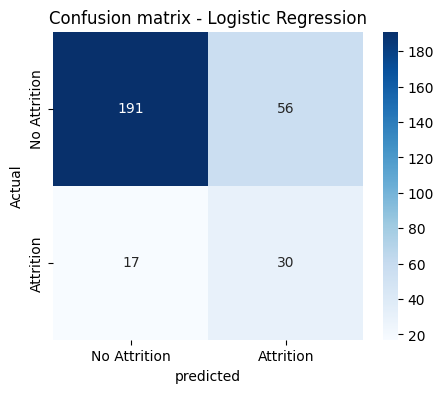

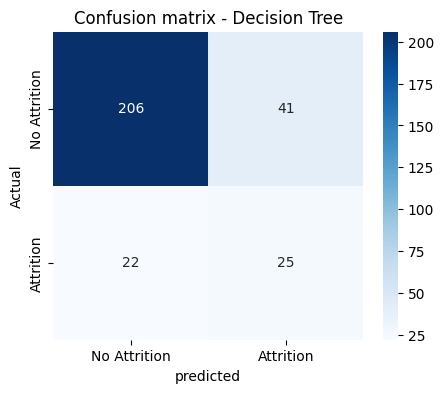

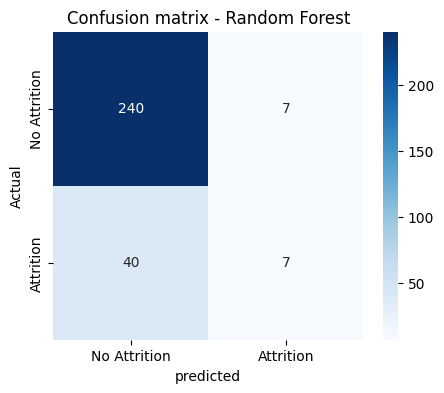

In [35]:
for name in models:
  cm = confusion_matrix(
      y_test,
      predictions[name]
  )

  plt.figure(figsize=(5,4))
  sns.heatmap(
      cm,
      annot=True,
      fmt="d",
      cmap="Blues",
      xticklabels=["No Attrition","Attrition"],
      yticklabels=["No Attrition","Attrition"]
  )

  plt.title(f"Confusion matrix - {name}")
  plt.xlabel("predicted")
  plt.ylabel("Actual")
  plt.show()

## 25. ROC Curve Analysis

ROC curves are used to compare the ability of the models to distinguish
between employees who leave and employees who stay.

The ROC-AUC score summarizes the model's ability to discriminate between
the two classes across different classification thresholds.

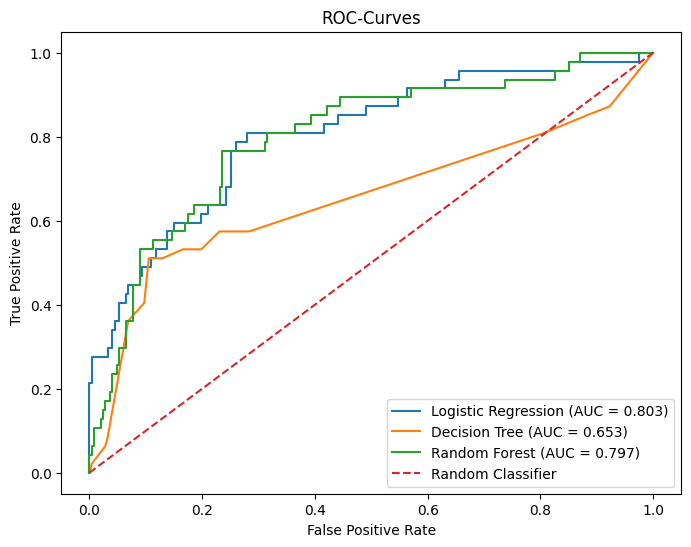

In [36]:
plt.figure(figsize=(8,6))

for name in models:
  y_prob = probabilities[name]
  fpr,tpr,thresholds = roc_curve(
      y_test,
      y_prob
  )

  auc_score = roc_auc_score(
      y_test,
      y_prob
  )

  plt.plot(
      fpr,
      tpr,
      label=f"{name} (AUC = {auc_score:.3f})"
  )
plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC-Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.show()


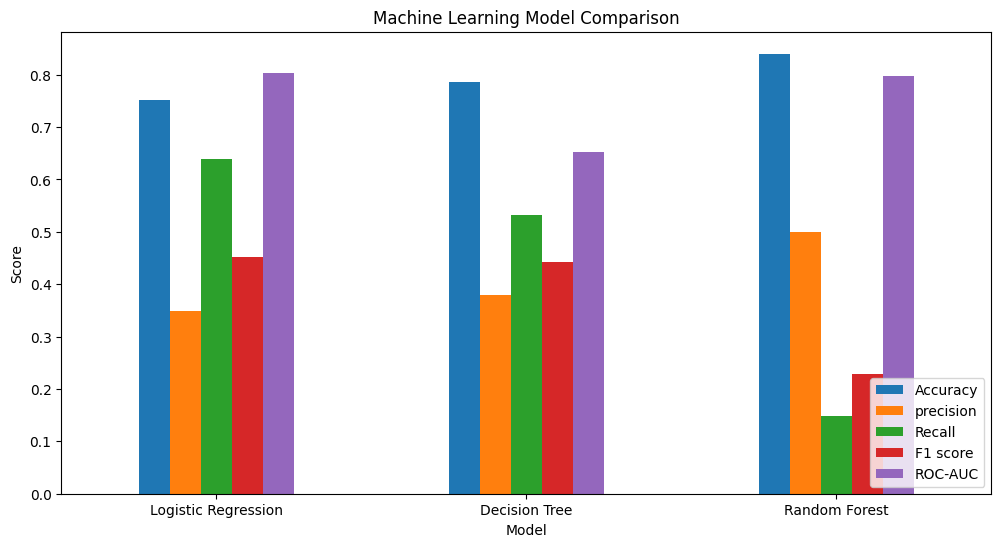

In [38]:
metrics = [
    "Accuracy",
    "precision",
    "Recall",
    "F1 score",
    "ROC-AUC"
]

results_plot = results_df.set_index("Model")[metrics]

results_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Machine Learning Model Comparison")
plt.ylabel("Score")
plt.xlabel("Model")

plt.xticks(rotation=0)
plt.legend(loc="lower right")

plt.show()

#**Find the Best Model**

In [41]:
best_model = results_df.loc[
    results_df['F1 score'].idxmax()
]
print("Best Model based on F1 score:")
print(best_model)

Best Model based on F1 score:
Model        Logistic Regression
Accuracy                0.751701
precision               0.348837
Recall                  0.638298
F1 score                0.451128
ROC-AUC                  0.80317
Name: 0, dtype: object


In [56]:
best_auc_model = results_df.loc[
    results_df['ROC-AUC'].idxmax()
]
print("Best Model based on ROC-AUC:")
print(best_auc_model)

Best Model based on ROC-AUC:
Model        Logistic Regression
Accuracy                0.751701
precision               0.348837
Recall                  0.638298
F1 score                0.451128
ROC-AUC                  0.80317
Name: 0, dtype: object


#**Feature Importance**

## 26. Feature Importance Analysis

Feature importance is analyzed using the Random Forest model to
identify which input variables contributed most strongly to the
model's predictions.

Feature importance indicates predictive contribution to the model and
does not necessarily imply a causal relationship with employee
attrition.

In [44]:
rf_pipeline = random_forest_model
rf_model = rf_pipeline.named_steps["model"]
preprocessor_fitted = rf_pipeline.named_steps["preprocessor"]

In [45]:
feature_names = preprocessor_fitted.get_feature_names_out()

In [46]:
importances = rf_model.feature_importances_

In [47]:
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

In [48]:
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

In [49]:
top_features = feature_importance_df.head(15)

print(top_features)

                      Feature  Importance
9          num__MonthlyIncome    0.075160
0                    num__Age    0.062478
16     num__TotalWorkingYears    0.054251
19        num__YearsAtCompany    0.049270
1              num__DailyRate    0.047074
2       num__DistanceFromHome    0.042910
10           num__MonthlyRate    0.040353
11    num__NumCompaniesWorked    0.040248
5             num__HourlyRate    0.040059
22  num__YearsWithCurrManager    0.039782
15      num__StockOptionLevel    0.032823
49           cat__OverTime_No    0.032568
50          cat__OverTime_Yes    0.031426
12     num__PercentSalaryHike    0.029783
20    num__YearsInCurrentRole    0.028931


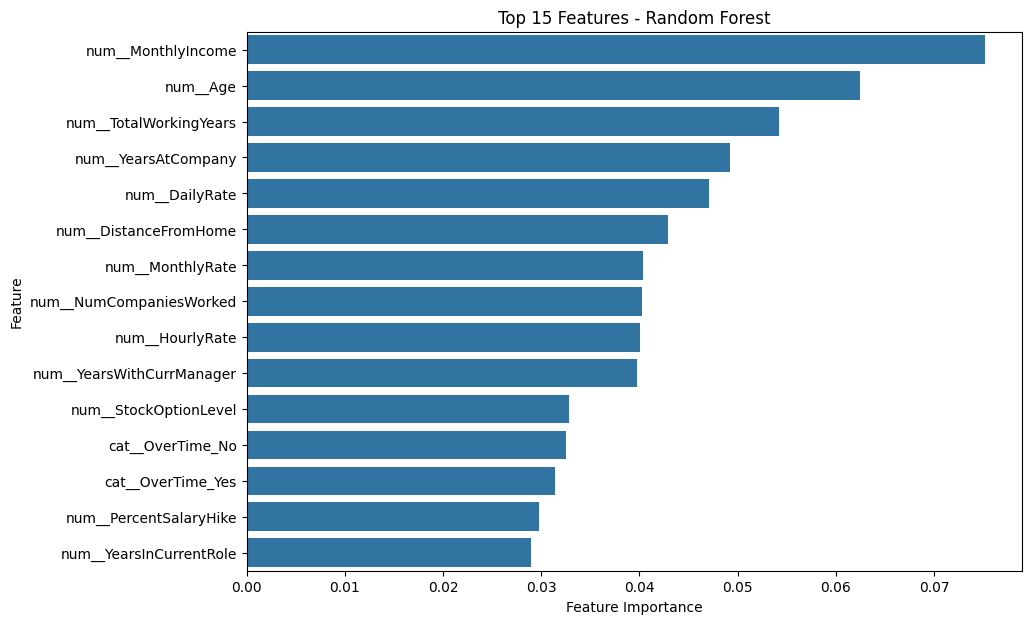

In [50]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Features - Random Forest")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.show()

In [53]:
sample_employee = x_test.iloc[[0]]

prediction = logistic_model.predict(
    sample_employee
)

probability = logistic_model.predict_proba(
    sample_employee
)[0][1]

print("Predicted Attrition:", prediction[0])
print("Probability of Attrition:", round(probability * 100, 2), "%")
if prediction[0] == 1:
    print("Prediction: Employee may leave")
else:
    print("Prediction: Employee may stay")

Predicted Attrition: 0
Probability of Attrition: 28.66 %
Prediction: Employee may stay


#**Conclusion**

This project successfully developed and evaluated machine learning models for predicting employee attrition using an HR dataset containing 1,470 employee records. The dataset was first explored and checked for data quality, with no missing values or duplicate records identified. Exploratory Data Analysis was then performed to understand the relationship between employee characteristics and attrition.

The data was prepared by removing non-informative columns, separating the input features from the target variable, encoding categorical variables using one-hot encoding, and scaling numerical features. Since the target variable was imbalanced, balanced class weights were used during model training. The dataset was divided into training and testing sets using an 80:20 split.

Three classification algorithms were evaluated: Logistic Regression, Decision Tree, and Random Forest. Random Forest achieved the highest overall accuracy of 84%, followed by Decision Tree at 79% and Logistic Regression at 75%. However, accuracy alone was not considered sufficient because only 237 of the 1,470 employees belonged to the attrition class.

For the important Attrition class, Logistic Regression achieved a recall of 64% and an F1-score of 0.45, while Decision Tree achieved a recall of 53% and an F1-score of 0.44. Random Forest achieved a higher precision of 50% but had a much lower recall of only 15% and an F1-score of 0.23. This indicates that although Random Forest produced the highest overall accuracy, it failed to identify many employees who actually left the organization.

Therefore, based on the objective of identifying potential employee attrition, Logistic Regression provided the most balanced performance among the tested models because it detected a larger proportion of actual attrition cases. Random Forest may appear stronger when considering accuracy alone, but its low attrition recall makes it less suitable when detecting potential employee departures is the primary objective.

Overall, this project demonstrated the complete supervised machine learning workflow, including data cleaning, exploratory data analysis, preprocessing, model training, handling class imbalance, model evaluation, confusion matrix analysis, ROC analysis, and feature importance. The project also demonstrated the importance of selecting evaluation metrics based on the actual business objective rather than relying only on overall accuracy.

The resulting models can be considered as decision-support tools for identifying employees who may be at higher risk of leaving. However, model predictions should not be treated as definitive explanations of employee behavior or as the sole basis for employment decisions.